In [15]:
import numpy as np                           
import pandas as pd                                 
import matplotlib.pyplot as plt 

from sklearn.pipeline import Pipeline           
from sklearn.compose import ColumnTransformer     
from sklearn.preprocessing import StandardScaler, RobustScaler      
from sklearn.preprocessing import OneHotEncoder       
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.model_selection import train_test_split, learning_curve

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

In [2]:
data = pd.read_csv("..\\data\\train_clean.csv")
data.head()

,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Power,Price,Brand,Model
0,Mumbai,2010,72000,CNG,Manual,First,26.0,58.0,1.75,MARUTI,WAGON R LXI CNG
1,Pune,2015,41000,Diesel,Manual,First,19.0,126.0,12.50,HYUNDAI,CRETA 1.6 CRDI SX OPTION
2,Chennai,2011,46000,Petrol,Manual,First,18.0,88.0,4.50,HONDA,JAZZ V
3,Chennai,2012,87000,Diesel,Manual,First,20.0,88.0,6.00,MARUTI,ERTIGA VDI
4,Coimbatore,2013,40670,Diesel,Automatic,Second,15.0,140.0,17.74,AUDI,A4 NEW 2.0 TDI MULTITRONIC


In [3]:
X = data.drop(columns=["Price"])
y = data["Price"] 

In [13]:
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

numeric_transformer = Pipeline(steps=[                       
    ("scaler", RobustScaler())                       
])
categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))     
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),     
        ("cat", categorical_transformer, categorical_features)  
    ]
)

In [14]:
X_train, X_test, y_train, y_test = train_test_split( 
    X, y,                                             
    test_size=0.2,                                   
    random_state=42                                   
)

In [6]:
ridge_model1 = Pipeline(steps=[
    ("preprocess", preprocess),                      
    ("model", Ridge())                    
])

ridge_model1.fit(X_train, y_train)                 
print("Ridge model trained.")

Ridge model trained.


In [7]:
def evaluate_regression(model, X_test, y_test, name="model"):
    """
    Evaluate a regression model on the test set using:
    - MAE
    - RMSE
    - R²
    Also plots Actual vs Predicted.
    """
    preds = model.predict(X_test)                     

    mae = mean_absolute_error(y_test, preds)   
    mse = mean_squared_error(y_test, preds)       
    rmse = root_mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)                      

    print(f"\n--- {name} ---")                        
    print(f"MAE : {mae:.4f}")  
    print(f"MSE: {mse:.4f}")                        
    print(f"RMSE: {rmse:.4f}")                        
    print(f"R^2 : {r2:.4f}")                          

    plt.figure()                                      
    plt.scatter(y_test, preds, s=8)                   
    plt.title(f"{name}: Actual vs Predicted")         
    plt.xlabel("Actual")                              
    plt.ylabel("Predicted")                           
    plt.show()                                        

    return mae, mse, rmse, r2 


--- Ridge ---
MAE : 2.1263
MSE: 18.9713
RMSE: 4.3556
R^2 : 0.8460


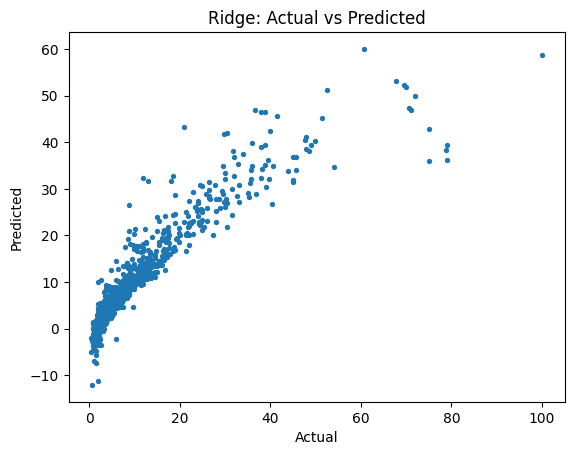

In [8]:
linreg_scores = evaluate_regression(                
    ridge_model1,                                   
    X_test,                                          
    y_test,                                          
    "Ridge"                         
)

In [40]:
ridge_model2 = Pipeline(steps=[
    ("preprocess", preprocess),                      
    ("model", Ridge(alpha=0.1, solver='sparse_cg', fit_intercept=True))                    
])

ridge_model2.fit(X_train, y_train)                 
print("Ridge model trained.")

Ridge model trained.



--- Ridge ---
MAE : 2.0540
MSE: 18.6097
RMSE: 4.3139
R^2 : 0.8490


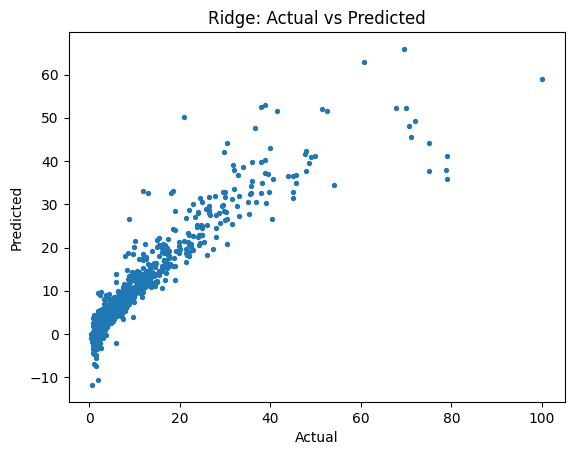

In [41]:
linreg_scores = evaluate_regression(                
    ridge_model2,                                   
    X_test,                                          
    y_test,                                          
    "Ridge"                         
)

**Essaie avec StandardScaler**

In [9]:
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

numeric_transformer = Pipeline(steps=[                       
    ("scaler", StandardScaler())                       
])
categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))     
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),     
        ("cat", categorical_transformer, categorical_features)  
    ]
)

In [10]:
X_train, X_test, y_train, y_test = train_test_split( 
    X, y,                                             
    test_size=0.2,                                   
    random_state=42                                   
)

In [11]:
ridge_model_standard = Pipeline(steps=[
    ("preprocess", preprocess),                      
    ("model", Ridge())                    
])

ridge_model_standard.fit(X_train, y_train)                 
print("Ridge model trained.")

Ridge model trained.



--- Ridge ---
MAE : 2.1265
MSE: 18.9621
RMSE: 4.3546
R^2 : 0.8461


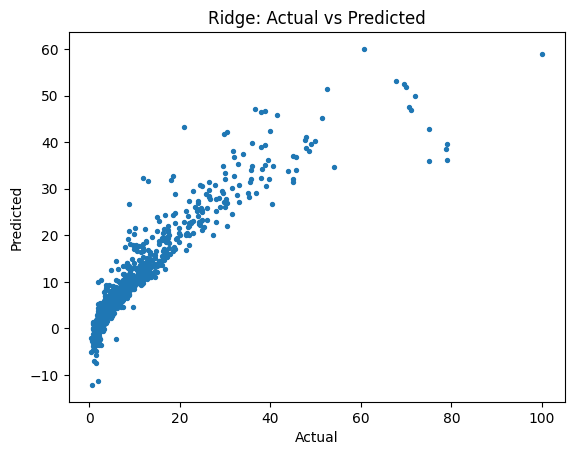

In [12]:
linreg_scores = evaluate_regression(                
    ridge_model_standard,                                   
    X_test,                                          
    y_test,                                          
    "Ridge"                         
)

**^Surprenament, les résultats sont très légèrement meilleurs en utilisant StandardScaler (mais la différence reste minime)**